100%|██████████| 170M/170M [00:04<00:00, 38.4MB/s]



--- Обучение: Stop-Gradient ВКЛЮЧЕН ---
Эпоха [1/20] | Loss: -0.6539 | Std: 0.0296
Эпоха [2/20] | Loss: -0.6725 | Std: 0.0332
Эпоха [3/20] | Loss: -0.7404 | Std: 0.0339
Эпоха [4/20] | Loss: -0.7288 | Std: 0.0357
Эпоха [5/20] | Loss: -0.7294 | Std: 0.0383
Эпоха [6/20] | Loss: -0.7443 | Std: 0.0393
Эпоха [7/20] | Loss: -0.7468 | Std: 0.0396
Эпоха [8/20] | Loss: -0.7446 | Std: 0.0400
Эпоха [9/20] | Loss: -0.7531 | Std: 0.0394
Эпоха [10/20] | Loss: -0.7514 | Std: 0.0401
Эпоха [11/20] | Loss: -0.7447 | Std: 0.0410
Эпоха [12/20] | Loss: -0.7394 | Std: 0.0418
Эпоха [13/20] | Loss: -0.7405 | Std: 0.0421
Эпоха [14/20] | Loss: -0.7379 | Std: 0.0424
Эпоха [15/20] | Loss: -0.7361 | Std: 0.0428
Эпоха [16/20] | Loss: -0.7352 | Std: 0.0431
Эпоха [17/20] | Loss: -0.7395 | Std: 0.0431
Эпоха [18/20] | Loss: -0.7400 | Std: 0.0434
Эпоха [19/20] | Loss: -0.7370 | Std: 0.0435
Эпоха [20/20] | Loss: -0.7357 | Std: 0.0436

--- Обучение: Stop-Gradient ВЫКЛЮЧЕН ---
Эпоха [1/20] | Loss: -0.8874 | Std: 0.0149
Эпо

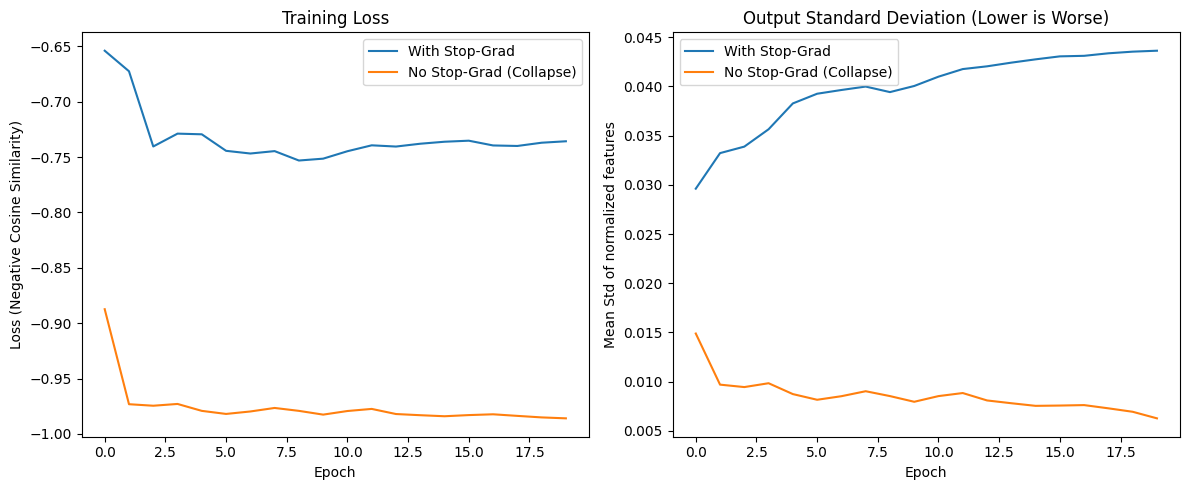

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np

# 1. Настройки и Аугментации (как в SimSiam, но для 32x32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 128
epochs = 20  # Для наглядности коллапса достаточно 20 эпох

# Две разные аугментации для одного изображения
class SiameseTransform:
    def __init__(self, transform):
        self.transform = transform
    def __call__(self, x):
        return [self.transform(x), self.transform(x)]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=SiameseTransform(transform_train))
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

# 2. Модель SimSiam
class SimSiam(nn.Module):
    def __init__(self, base_encoder):
        super(SimSiam, self).__init__()
        # Убираем последний слой ResNet
        self.encoder = nn.Sequential(*list(base_encoder.children())[:-1])

        # Projector MLP
        self.projector = nn.Sequential(
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 512), nn.BatchNorm1d(512)
        )

        # Predictor MLP (Асимметрия!)
        self.predictor = nn.Sequential(
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 512)
        )

    def forward(self, x1, x2, use_stop_grad=True):
        z1, z2 = self.projector(self.encoder(x1).flatten(1)), self.projector(self.encoder(x2).flatten(1))
        p1, p2 = self.predictor(z1), self.predictor(z2)

        if use_stop_grad:
            # Считаем лосс с остановкой градиента (как в статье)
            loss = self.D(p1, z2.detach()) / 2 + self.D(p2, z1.detach()) / 2
        else:
            # Считаем лосс БЕЗ остановки градиента (коллапс)
            loss = self.D(p1, z2) / 2 + self.D(p2, z1) / 2

        return loss, z1 # z1 возвращаем для расчета std (проверка коллапса)

    def D(self, p, z): # Отрицательное косинусное сходство
        p = nn.functional.normalize(p, dim=1)
        z = nn.functional.normalize(z, dim=1)
        return -(p * z).sum(dim=1).mean()

# 3. Функция тренировки
def train_model(use_stop_grad):
    print(f"\n--- Обучение: Stop-Gradient {'ВКЛЮЧЕН' if use_stop_grad else 'ВЫКЛЮЧЕН'} ---")
    model = SimSiam(resnet18()).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.03, momentum=0.9, weight_decay=5e-4)

    loss_history = []
    std_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_std = 0
        for i, (images, _) in enumerate(trainloader):
            img1, img2 = images[0].to(device), images[1].to(device)

            optimizer.zero_grad()
            loss, z = model(img1, img2, use_stop_grad=use_stop_grad)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            # Считаем std нормализованных векторов (близость к 0 = коллапс)
            with torch.no_grad():
                z_norm = nn.functional.normalize(z, dim=1)
                std = z_norm.std(dim=0).mean()
                epoch_std += std.item()

        avg_loss = epoch_loss / len(trainloader)
        avg_std = epoch_std / len(trainloader)
        loss_history.append(avg_loss)
        std_history.append(avg_std)
        print(f"Эпоха [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Std: {avg_std:.4f}")

    return loss_history, std_history

# 4. Запуск экспериментов
history_with_sg = train_model(use_stop_grad=True)
history_no_sg = train_model(use_stop_grad=False)

# 5. Визуализация
plt.figure(figsize=(12, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(history_with_sg[0], label='With Stop-Grad')
plt.plot(history_no_sg[0], label='No Stop-Grad (Collapse)')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Cosine Similarity)')
plt.legend()

# График Std (Показатель коллапса)
plt.subplot(1, 2, 2)
plt.plot(history_with_sg[1], label='With Stop-Grad')
plt.plot(history_no_sg[1], label='No Stop-Grad (Collapse)')
plt.title('Output Standard Deviation (Lower is Worse)')
plt.xlabel('Epoch')
plt.ylabel('Mean Std of normalized features')
plt.legend()

plt.tight_layout()
plt.savefig('simsiam_collapse_result.png')
plt.show()